# La Liga, by its numbers: backing football intuition with data

**What this is.** A football-analytics study of six La Liga seasons (2020/21–2025/26). I take the things
"football-heads" already believe in — *chance quality wins matches, possession is overrated, there's more than
one way to be a good team* — and check them, with machine learning and statistics.

**The honest framing.** None of the conclusions here is *revolutionary* to someone who watches a lot of
football. That is the point. The contribution is not a surprising new claim; it is that these intuitions are
now **backed by a rigorous study of my own** — measured on real data, with leak-free method, proper scoring,
significance testing. Where
the data could not support a claim, I say so. The project even started as a betting-edge hunt and reached a
clean **negative result**.

**How to read it.** Top to bottom. The raw data is licensed, so it is not in the public repo — that means the
code cells below were run once and their outputs are saved into this notebook, so you can read everything here
without installing anything. Each method is explained in one plain sentence the first time it appears.

In [1]:
# Run from the repo root so data/ and docs/ paths resolve, wherever this notebook is opened from.
import os, sys
while not os.path.isdir("src") and os.getcwd() != "/":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd
from IPython.display import Image, display
from src.data_tool import explanatory_rank, team_profile, team_style, xpts, team_card, exhibits, chance_creation
from src.data_tool.team_profile import team_seasons
pd.set_option("display.max_columns", 20)
print("working dir:", os.path.basename(os.getcwd()))

working dir: laliga-analytics-engine


## The raw material

Six seasons of La Liga from a single licensed API: **54 team-level** and **48 player-level** stat columns
per match (expected goals, big chances, shot location, passing, duels, defensive actions, goalkeeping;
per-player rating, xG, minutes), across **2,280 matches**.

In [2]:
ts, _ = team_seasons()
matches = pd.read_csv("data/raw/thestatsapi/matches.csv", low_memory=False)
ll = matches[matches.comp_name == "La Liga"] if "comp_name" in matches else matches
print(f"team-seasons: {len(ts)}   seasons: {sorted(ts.season.unique())}")
print(f"La Liga matches on record: {ll.match_id.nunique() if 'match_id' in ll else len(ll)}")
ts[["team_name", "season", "ball_possession", "pass_accuracy", "points", "elo_pre"]].head(3)

team-seasons: 120   seasons: ['20/21', '21/22', '22/23', '23/24', '24/25', '25/26']
La Liga matches on record: 2280


,team_name,season,ball_possession,pass_accuracy,points,elo_pre
0,Real Sociedad,20/21,55.000000,0.797495,62,1539.971420
1,Real Sociedad,21/22,54.789474,0.812358,62,1577.571995
2,Real Sociedad,22/23,54.947368,0.812837,71,1600.403655


## 1. What actually decides a match?

**The question.** Of all the things we measure in a game — shots, possession, passing, duels, chance quality
(*expected goals*, "xG": the number of goals an average team would score from those chances) — which ones
actually separate winners from losers?

**The method, in one sentence.** I trained tree-ensemble models to read the 1X2 result from each match's stats,
then measure each stat by **permutation importance**: shuffle that one stat in the held-out test set and see how
much the model's score (log-loss — lower is better) gets worse. A stat that matters a lot, hurts a lot when scrambled.

**The honesty step.** Some stats *mechanically restate the score* — a goal IS a shot on target; a keeper's
"goals prevented" already contains goals conceded. Those aren't *drivers*, they're the result wearing a
disguise. I remove them (a **partial-correlation** check separates a real driver from a score-echo) and rank
what's left.

,stat,importance
0,Chance quality (xG),0.4939
1,Shots,0.0157
2,Passing,0.0082
3,Tackles,0.0029
4,Possession,0.0010


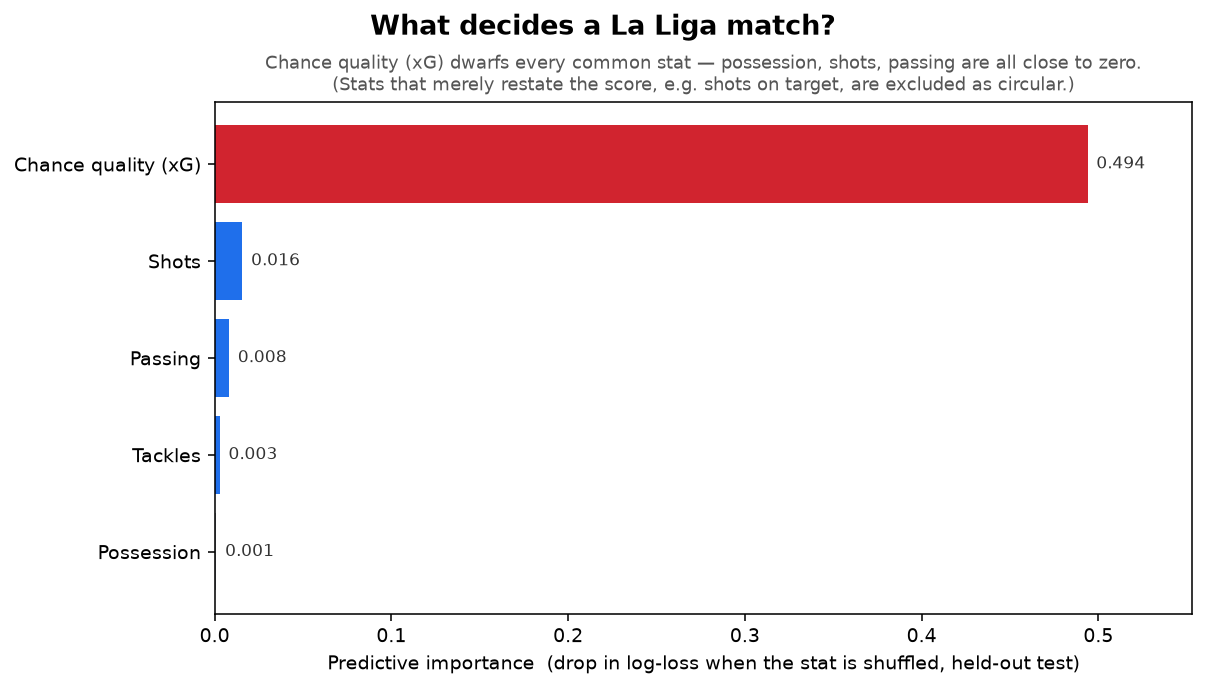

In [3]:
rank = {r["feature"]: r["mean_perm_logloss_drop"] for r in explanatory_rank.run()["frame_C_clean"]["ranking"]}
tbl = pd.DataFrame([{"stat": exhibits.nice(f), "importance": round(rank[f], 4)}
                    for f in exhibits.WHAT_DECIDES_SHOW if f in rank])
display(tbl)
display(Image(filename="docs/figures/what_decides_a_match.png"))

**What it means.** Once the score-echoes are gone, **chance quality (xG) is the only clean driver, and it
dominates everything else** — more than thirty times the next stat. **Possession is statistically indistinguishable
from zero.** A football person will shrug: *of course you win by creating better chances, not by passing it around
in front of the defence.* Now it is measured, on 2,280 matches, with the score-echoes stripped out.

## 1b. What is "chance creation" actually made of?

xG is the driver — but it's an *output*. What produces it? It splits into two **near-separate skills**:
**shot volume** (how many shots) and **shot quality** (how good each one is — and quality is almost
entirely *location*: shots from inside the box are good, shots from distance are not). A team can be strong
on one and weak on the other; the two barely correlate.

And it sharpens the possession point: **possession buys volume, not quality** — hold shot count fixed and
possession adds nothing to xG (it earns more shots, not better ones). The harder, discriminating step is
**getting into the box**: reaching the final third is cheap, converting that into box presence is the skill,
and it comes from passing quality, crosses and carrying — *not* from long balls.

*The current data bottleneck.* A real **open-play vs set-piece vs counter-attack** breakdown would need
shot-by-shot event data, which this API doesn't provide — so that deeper split is simply out of reach here.
The limit is more data, not method.

In [4]:
cc = chance_creation.run()
tl = cc["two_levers"]
print(f"xG = shots x quality.  corr(shots,xG)={tl['corr_shots_xg']:+.2f}  corr(quality,xG)={tl['corr_quality_xg']:+.2f}  "
      f"corr(shots,quality)={tl['corr_shots_quality']:+.2f}  (~0 -> near-separate skills)")
print("Possession buys shots, not better shots (the xG link vanishes once shot count is held fixed):")
for v, d in cc["volume_not_quality"].items():
    print(f"   {v:24} corr {d['corr_xg']:+.2f}  ->  partial | shots {d['partial_xg_given_shots']:+.2f}")
b = cc["box_penetration"]
print(f"Getting into the box is the harder step:  possession->final-third {b['possession_to_final_third']:+.2f}, "
      f"final-third->box {b['final_third_to_box']:+.2f} (weaker)")

xG = shots x quality.  corr(shots,xG)=+0.68  corr(quality,xG)=+0.74  corr(shots,quality)=+0.06  (~0 -> near-separate skills)
Possession buys shots, not better shots (the xG link vanishes once shot count is held fixed):
   ball_possession          corr +0.27  ->  partial | shots -0.04
   pass_final_third_entries corr +0.15  ->  partial | shots -0.12
   pass_accurate_crosses    corr +0.27  ->  partial | shots -0.12
Getting into the box is the harder step:  possession->final-third +0.57, final-third->box +0.37 (weaker)


## 2. Can we *predict* the result before kickoff?

Explaining a finished match is one thing; forecasting the next one — using **only information known before
kickoff** (no leakage) — is harder. The workhorse is **Elo**: a running team-strength rating that goes up when
you win and down when you lose, weighted by the opponent's rating. It is built only from past results.

I rolled the chance-quality signal into a strictly pre-match form and asked: *does it add anything on top of
Elo?* Scored honestly out-of-sample (RPS / log-loss — proper scoring rules that reward well-calibrated
probabilities, not just right/wrong).

**The result — and the ceiling.** Elo dominates. Pre-match xG helps only as a slow-moving *strength* signal,
is about 60% redundant with Elo, and its extra edge is **within the noise** a ~750-match test can resolve —
directionally positive, but not provable. *Explaining a match and predicting it are not the same skill.* And
the honest headline is a **ceiling**: a single La Liga match is mostly latent team strength plus irreducible
luck. (A further leak-free test confirmed it: even a feature for *who actually starts today* — the one thing Elo can't
see — could not beat Elo. The only way to more accuracy is more data, not more features.)

## 3. What makes a team *good*? (turning the ceiling into a question worth asking)

Since predicting single matches hits a wall, I flipped the question: instead of fighting the team-strength
rating, use it as the **target**. *What does a high-Elo team look like?*

Great teams win the obvious way — they create more and better chances (true by construction, since the rating
is built from results). The interesting part is the **style signature** that survives once you control for
scoring: great La Liga teams **dominate the ball** (passing volume and accuracy), **get into the box more**
(territorial penetration), **foul and card less** (discipline), and make **fewer desperate defensive actions**
(they hold the ball, so they're not under siege).

**The famous nuance, measured.** Possession **marks** quality between teams (correlation 0.69 with strength) but
does **not decide** a single match once quality is held fixed (partial correlation ≈ −0.12). Possession is a
*symptom* of being the better side, sitting alongside winning rather than causing it.

In [5]:
prof = team_profile.run()
bd = prof["ball_domination_construct"]
print(f"Ball-domination beyond just scoring: partial corr {bd['partial_vs_elo_given_goaldiff']:+.2f}, "
      f"but only +{bd['incremental_r2']:.3f} extra R^2 -> REAL but SMALL.")
print(f"Possession marks quality (corr {prof['possession_paradox']['corr_possession_vs_elo']}) "
      f"but does not decide a match once quality is fixed (partial ~ -0.12).")

Ball-domination beyond just scoring: partial corr +0.24, but only +0.007 extra R^2 -> REAL but SMALL.
Possession marks quality (corr 0.685) but does not decide a match once quality is fixed (partial ~ -0.12).


## 4. Is there one "right" way to play? — the style map (and a finding I had to walk back)

If great teams *on average* dominate the ball, does that mean there's a single main recipe? Atlético says no:
win without much of the ball; Barça win with most of it. I tried to make this precise by **clustering** team-seasons
into named style archetypes (possession / direct / high-press / low-block), controlling for quality.

**The honest result, after correcting my first version.** A closer look showed my "named archetypes / multiple routes to greatness" claim was
**circular** — and that there are, in fact, **no discrete style clusters at all**. La Liga style is a
**continuum**, best described by two axes, not a set of tribes:

- **PC1**: possession / passing / dribbling  ↔  physical / aerial
- **PC2**: territorial penetration  ↔  deep / reactive

The honest, surviving statements: style is a smooth continuum (no archetypes); at fixed quality it is **almost
unrelated to greatness** — no single style makes a team great, and **no style "punches above" its strength**;
and the one robust specific finding is that **Atlético Madrid is a genuinely elite side built on a
non-possession identity** — the clear exception to "great = dominate the ball."

Discrete archetypes? -> CONTINUUM (no discrete archetypes)
  best silhouette 0.197 vs matched-noise 0.186 (p=0.263); Hopkins 0.613 (<0.75 = not clusterable)
  ~6.0 effective style dimensions
Does any style beat its Elo? PC1 vs points-above-Elo: rho 0.084 (p=0.362) -> no style over/under-performs its Elo


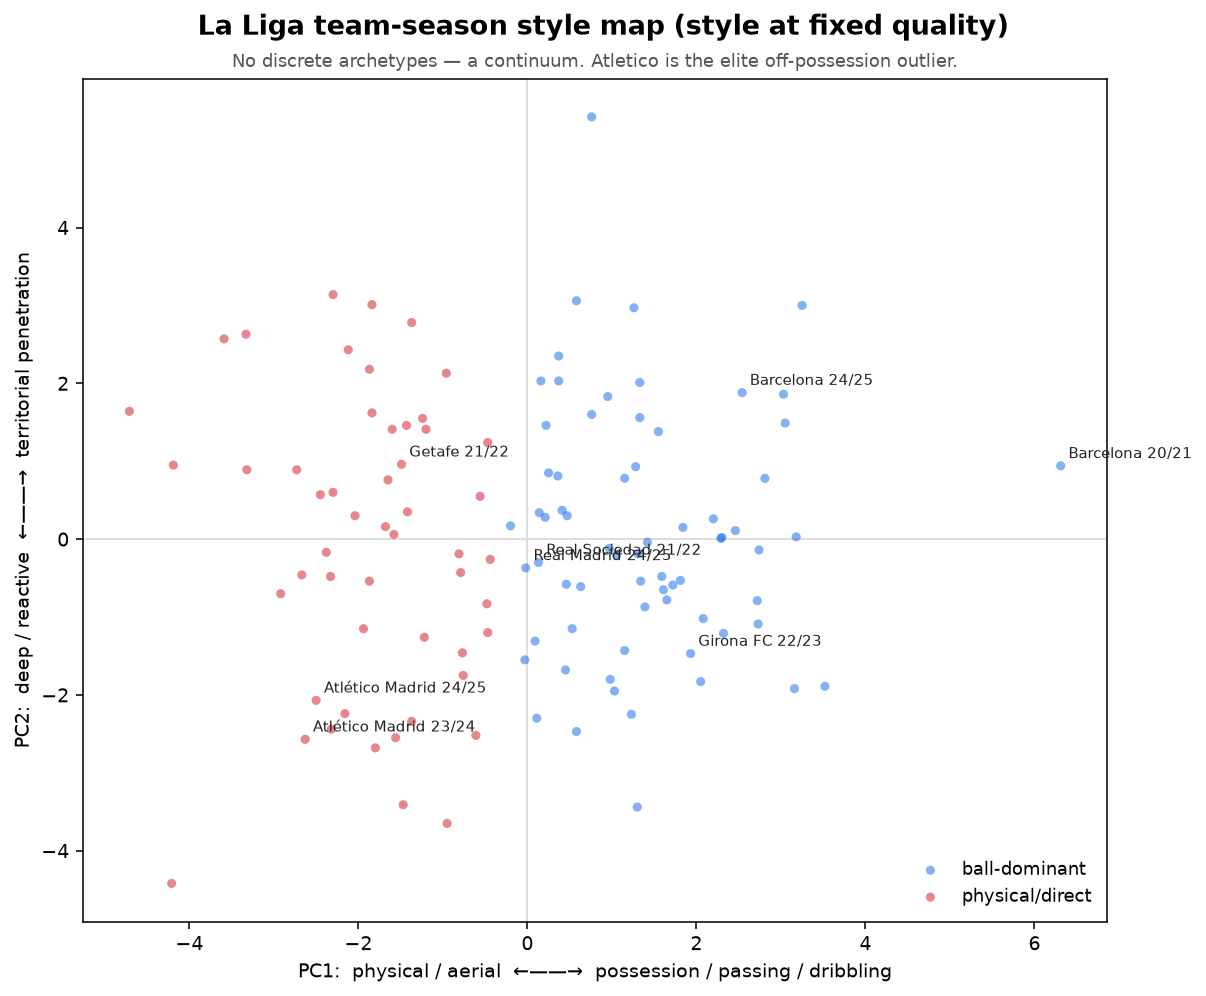

In [6]:
sty = team_style.run()
c = sty["clusterability"]; o = sty["style_quality_orthogonality"]
print(f"Discrete archetypes? -> {c['verdict']}")
print(f"  best silhouette {c['best_silhouette']} vs matched-noise {c['matched_noise_silhouette_mean']} "
      f"(p={c['matched_noise_p']}); Hopkins {c['hopkins']} (<0.75 = not clusterable)")
print(f"  ~{sty['style_map']['effective_dimensions']} effective style dimensions")
print(f"Does any style beat its Elo? PC1 vs points-above-Elo: rho "
      f"{o['style_predicts_points_beyond_elo']['spearman_PC1_vs_points_residual']} "
      f"(p={o['style_predicts_points_beyond_elo']['p']}) -> {o['style_predicts_points_beyond_elo']['verdict']}")
display(Image(filename="docs/figures/style_map.png"))

The map places every team-season on those two axes. Barça and Real Madrid sit far right (possession); Getafe and
the physical sides sit left; **Atlético sits at the off-possession extreme yet is elite** — the exception that
shows greatness has no single style. The CLI prints the same idea as a card:

In [7]:
team_card._print_card(team_card.card("Barcelona", "24/25"))
team_card._print_card(team_card.card("Atletico Madrid", "24/25"))


=== Barcelona -- 24/25 ===
Quality:   Elo 1762 (98th pct of all team-seasons) | 88 pts | GD +63 | finished 1st
Style:     ball-dominant pole | style-map position (PC1 +2.5, PC2 +1.9)
Key stats: possession 69.1% | pass accuracy 88.4% | aerial-duel share 10.1% | final-third entries 69.1/match
Read:      A ball-dominant top side -- the textbook 'great team' style.



=== Atlético Madrid -- 24/25 ===
Quality:   Elo 1697 (92nd pct of all team-seasons) | 76 pts | GD +38 | finished 3rd
Style:     physical/direct pole | style-map position (PC1 -2.5, PC2 -2.1)
Key stats: possession 52.4% | pass accuracy 84.6% | aerial-duel share 11.8% | final-third entries 50.8/match
Read:      An elite side winning WITHOUT dominating the ball -- the off-possession route to the top.


## 5. Who deserved what? — the xG table

A natural, football-friendly exhibit: how many points did each team's *chances* deserve, versus what they
actually got? For every match I treat the two teams' xG as two **Poisson** scoring rates (a standard way to turn
an average goal count into win/draw/loss probabilities), read off the expected points, and add them up over the
season. The gap to the real table is finishing/goalkeeping — skill, luck, or game-state — not chance creation.

,team,pts,xpts,over_perf,gd,xgd
0,Barcelona,88,78.7,9.3,63,50.5
1,Real Madrid,84,69.9,14.1,40,32.8
2,Atlético Madrid,76,68.6,7.4,38,30.9
3,Villarreal,70,65.1,4.9,20,20.4
4,Athletic Club,70,60.5,9.5,25,15.2
5,Celta Vigo,55,60.3,-5.3,2,12.4
6,Real Betis,60,56.0,4.0,7,3.9
7,Real Sociedad,46,51.4,-5.4,-11,-1.3


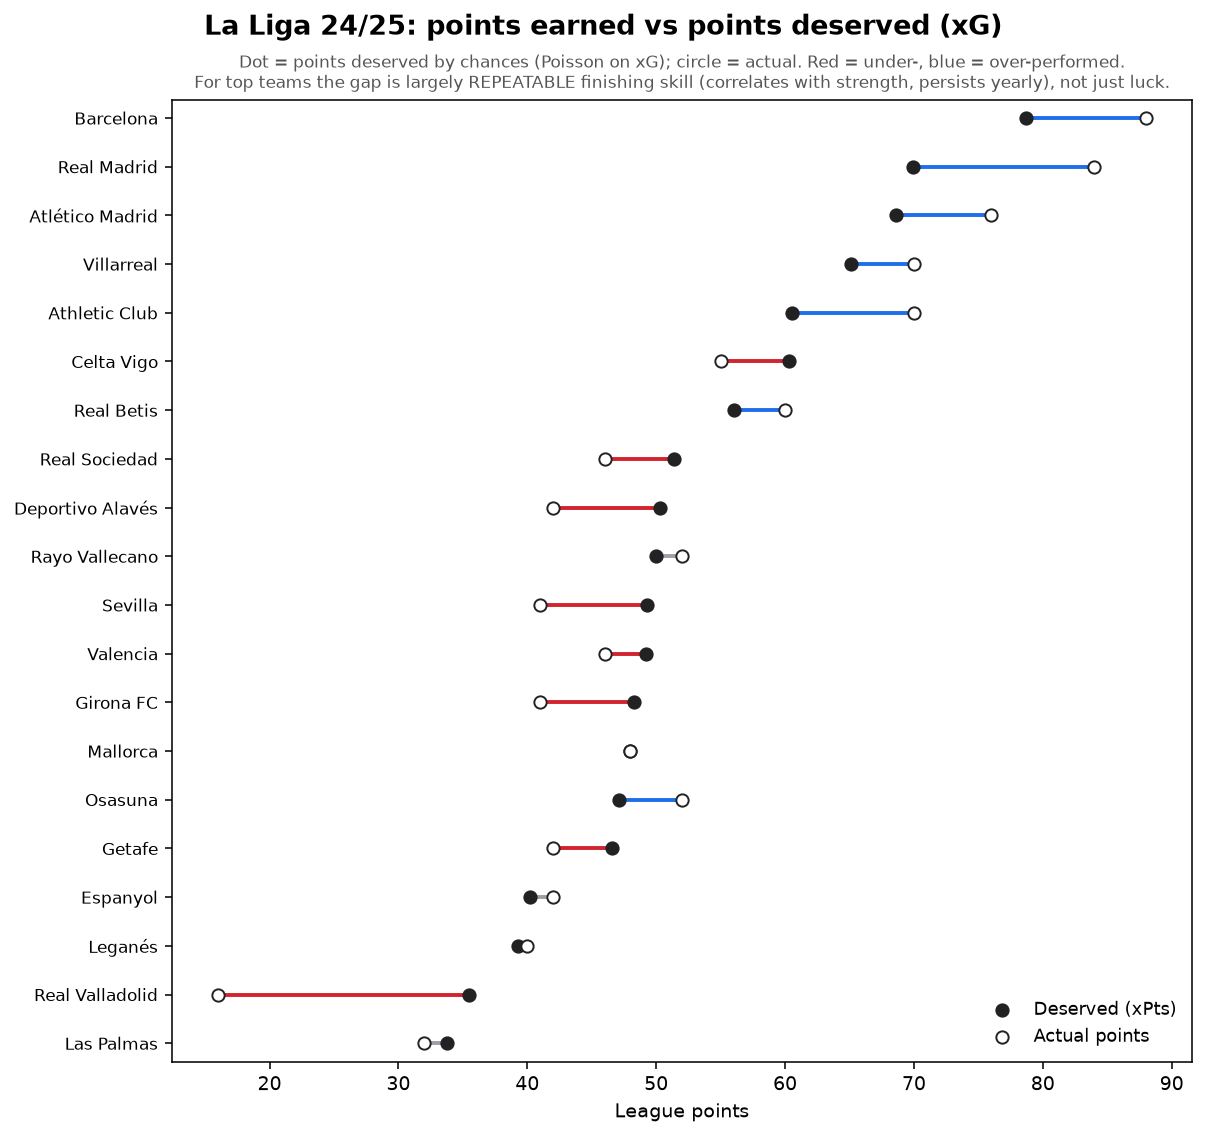

In [8]:
table = xpts.season_xg_table("24/25")
display(table[["team", "pts", "xpts", "over_perf", "gd", "xgd"]].head(8))
display(Image(filename="docs/figures/xg_expected_table.png"))

**Reading it.** In 2024/25 Real Madrid earned far more points than their chances deserved, and Valladolid far
fewer (and went down). *What the gap is — stated carefully:* over-performing your xG is **not just luck**. Across
the six seasons it correlates with team strength (r ≈ 0.6 with xG-for) and **persists year to year** (≈ 0.3–0.5),
so for the top sides it is largely **repeatable finishing and goalkeeping skill**, mixed with single-season
variance that one year can't fully separate. The estimator itself is unbiased — a zero-skill simulation (goals
drawn straight from xG) produces *no* such pattern, so the gap isn't an artifact of the method. This is
**descriptive**, not a forecast (it uses each finished match's own xG); the independent-Poisson step ignores the
tiny score correlation a Dixon-Coles term would add (≤ 0.5 pts per season — immaterial here).

## 6. The demo

A small command-line tool puts the engine in your hands. `card` shows a team's quality + style fingerprint;
`match` explains a finished game — the chances each side created, the points those chances deserved, and an
honest read of result versus deserved.

In [9]:
team_card._print_match(team_card.match("Barcelona", "Real Madrid", "24/25"))   # the 4-3 Clasico
team_card._print_match(team_card.match("Real Madrid", "Barcelona", "24/25"))   # the 0-4 at the Bernabeu


=== Barcelona 4-3 Real Madrid  (24/25) ===
Chances (xG):  Barcelona 4.26  -  2.74 Real Madrid
Deserved pts:  2.08  -  0.79   (win prob H/D/A: 0.65/0.13/0.22)
Possession:    62.0%  -  38.0%      Shots: 23 - 9
Read:          Chances and result broadly agree (deserved: Barcelona; result: Barcelona).

=== Real Madrid 0-4 Barcelona  (24/25) ===
Chances (xG):  Real Madrid 1.48  -  2.58 Barcelona
Deserved pts:  0.8  -  2.02   (win prob H/D/A: 0.21/0.18/0.61)
Possession:    41.0%  -  59.0%      Shots: 9 - 15
Read:          Chances and result broadly agree (deserved: Barcelona; result: Barcelona).


## The backstory: this began as a betting study

Before it was an analytics project, this was a hunt for a betting edge. The plan was ordinary: take the same box-score and xG data, train a model to estimate each match's true result probabilities, and bet wherever the model's number disagreed enough with the bookmaker's to imply value. An early backtest even looked promising — a positive return on paper.

The honest test killed it. A backtest return is easy to produce by luck, so the real question is **closing-line value (CLV)**: does the model beat the *closing* odds — the market's last and sharpest price just before kickoff — which is the cleanest yardstick for whether you actually know something the market doesn't. Measured that way, pre-registered and significance-tested on both the match-result and the over/under markets, the edge was **zero**. The promising backtest had been variance, not skill.

That is a clean, useful negative result: with public box-score + xG data there is no beating an efficient La Liga closing line — winning a market needs information the market lacks, not merely real patterns. So the project kept the data and the discipline and dropped the wager. The *same* data has real analytical value with no market-efficiency wall to fight — which is everything above.

*(No betting code or models are part of this repository — this section is the story, not a how-to.)*


## 7. The methodology:

The methods matter more than the headlines — none of which is a surprise to a football fan.
The discipline on display:

- **Leak-free features** — a predictive feature for a match on date *T* may use only what was knowable before
  *T*; verified with explicit leakage tests.
- **Explanation ≠ prediction** — a stat can explain a finished match yet add nothing to a forecast (xG is the clearest example).
- **Circularity audits** — separating a real driver from a score-echo with partial correlation.
- **Proper scoring + power analysis** — RPS / log-loss, and treating a non-significant result on a small sample as
  *"can't resolve"*, not *"no effect"*.

## Conclusion — what this demonstrates

The findings restate: **chances win games, possession is overrated, and there is more
than one way to be good.** What I am showing is not novelty but **method** — the ability to take an intuition, test
it rigorously and honestly on real data, know the difference between explaining and predicting, recognise a ceiling
instead of overfitting past it, and *report the result I found rather than the one I wanted*. That combination —
technical care, honest communication, and a clear head about what the data can and cannot say.